In [203]:
import pandas as pd

import seaborn as sns
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [204]:
# prompt: read the data set /data set.csv
df = pd.read_csv('data set.csv')


In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


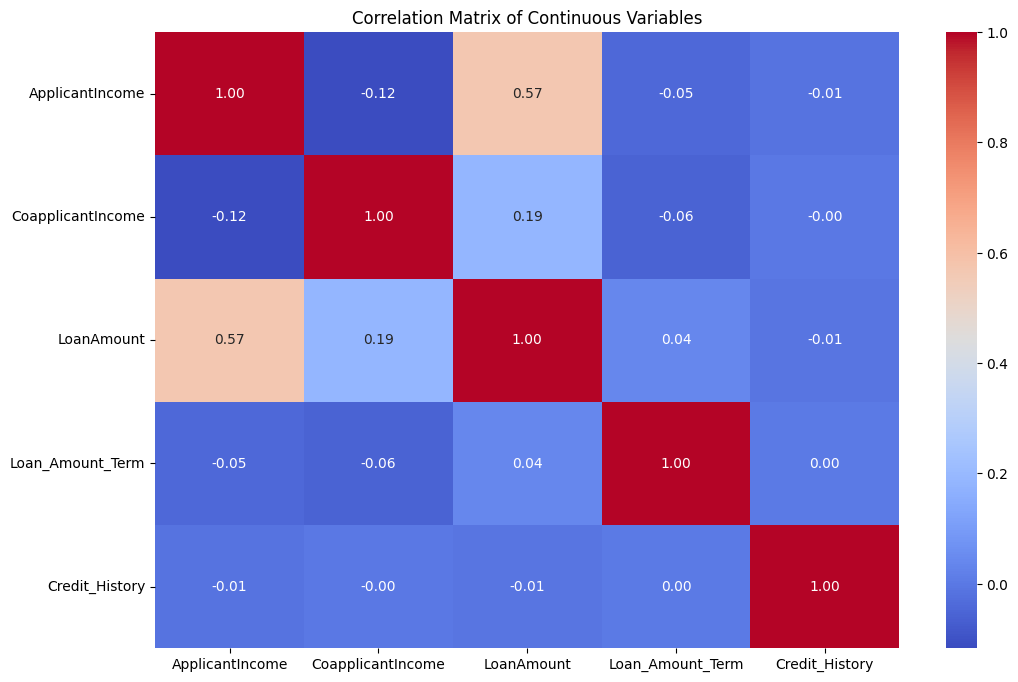

In [206]:
# prompt: generate a code for correlation on this data set

# Correlation Matrix for Continuous Variables
continuous_features = df.select_dtypes(include=['number']).columns
correlation_matrix = df[continuous_features].corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.show()


In [207]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [208]:
# Begin data cleaning and imputation

# Step 1: Imputation for categorical columns using mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 2: Imputation for numerical columns using median for LoanAmount and mode for Loan_Amount_Term, Credit_History already handled
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Verify that the dataset has no more missing values
missing_values_after_imputation = df.isnull().sum()

# Display cleaned data summary and check for any remaining missing values
df.info(), missing_values_after_imputation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


<ipython-input-208-2ef397e304df>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
<ipython-input-208-2ef397e304df>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

(None,
 Loan_ID              0
 Gender               0
 Married              0
 Dependents           0
 Education            0
 Self_Employed        0
 ApplicantIncome      0
 CoapplicantIncome    0
 LoanAmount           0
 Loan_Amount_Term     0
 Credit_History       0
 Property_Area        0
 Loan_Status          0
 dtype: int64)

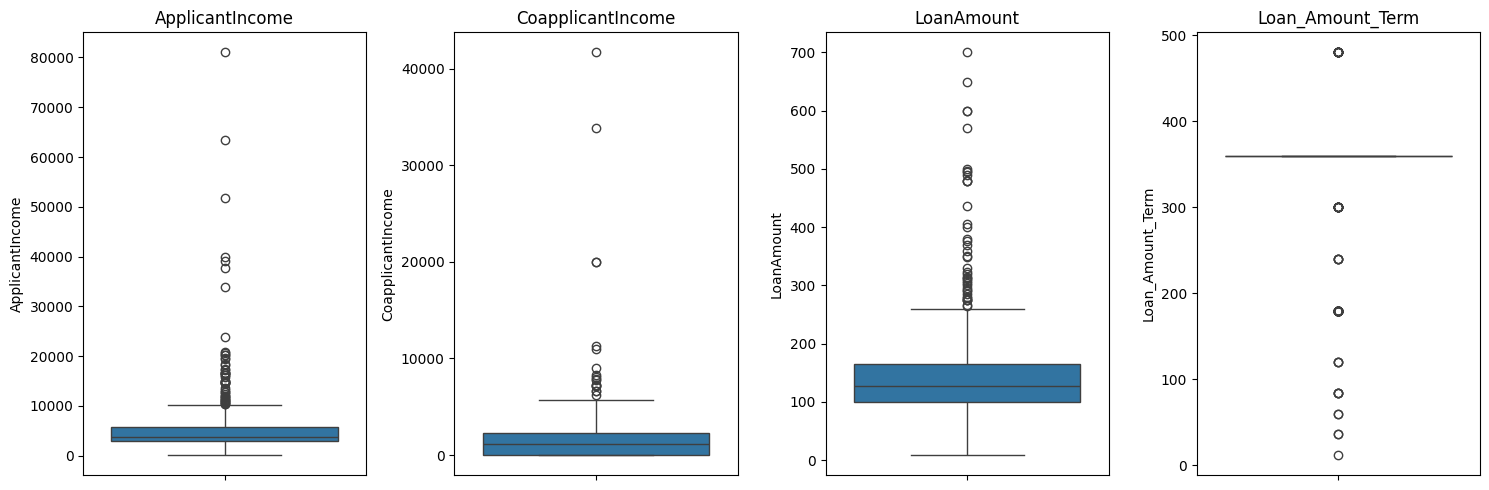

In [209]:
# prompt: check for outlier in ApplicantIncome , CoapplicantIncome , LoanAmount  , Loan_Amount_Term use box plot

import matplotlib.pyplot as plt

# Create box plots for the specified columns
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
sns.boxplot(y='ApplicantIncome', data=df)
plt.title('ApplicantIncome')

plt.subplot(1, 4, 2)
sns.boxplot(y='CoapplicantIncome', data=df)
plt.title('CoapplicantIncome')

plt.subplot(1, 4, 3)
sns.boxplot(y='LoanAmount', data=df)
plt.title('LoanAmount')

plt.subplot(1, 4, 4)
sns.boxplot(y='Loan_Amount_Term', data=df)
plt.title('Loan_Amount_Term')

plt.tight_layout()
plt.show()


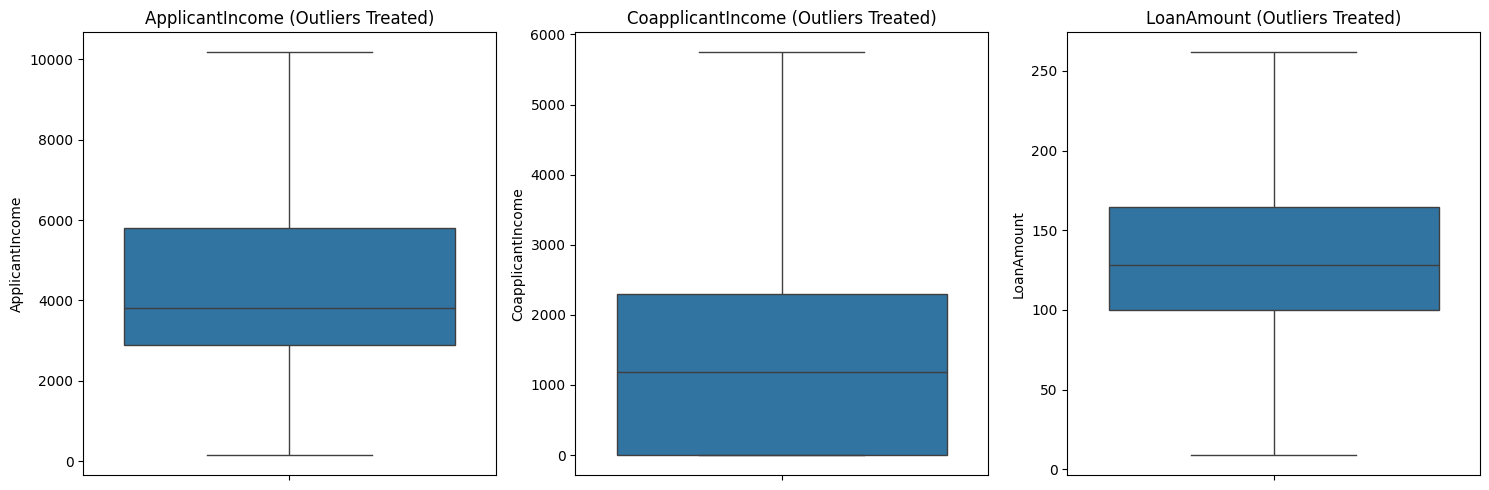

In [210]:
# prompt: treat outliers

# Define a function to treat outliers using IQR method
def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df


# Apply the function to the columns with outliers
df = treat_outliers_iqr(df, 'ApplicantIncome')
df = treat_outliers_iqr(df, 'CoapplicantIncome')
df = treat_outliers_iqr(df, 'LoanAmount')


# Plot the box plots again to see the effect of outlier treatment
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y='ApplicantIncome', data=df)
plt.title('ApplicantIncome (Outliers Treated)')

plt.subplot(1, 3, 2)
sns.boxplot(y='CoapplicantIncome', data=df)
plt.title('CoapplicantIncome (Outliers Treated)')

plt.subplot(1, 3, 3)
sns.boxplot(y='LoanAmount', data=df)
plt.title('LoanAmount (Outliers Treated)')

plt.tight_layout()
plt.show()


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    float64
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(5), object(8)
memory usage: 62.5+ KB


In [212]:
# prompt: do lable encoding in Gender , Married , Dependents  , Education , Self_Employed , Property_Area , Loan_Status

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply label encoding to the specified columns
for column in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
  df[column] = le.fit_transform(df[column])

df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


In [216]:
# prompt: TAKE NATURAL LOG OF ApplicantIncome , CoapplicantIncome ,

df['ApplicantIncome'] = np.log(df['ApplicantIncome'])
df['CoapplicantIncome'] = np.log1p(df['CoapplicantIncome'])


In [217]:
# prompt: drop Loan_ID

df = df.drop('Loan_ID', axis=1)


KeyError: "['Loan_ID'] not found in axis"

In [218]:
# prompt: split data into train and test in .7 and .3 respectively

from sklearn.model_selection import train_test_split

# Assuming 'Loan_Status' is your target variable
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [219]:
# prompt: DROP ApplicantIncome	CoapplicantIncome

X_train = X_train.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1)
X_test = X_test.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1)


In [220]:
X_train

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,CoapplicantIncome_log
553,1,1,0,1,0,181.0,360.0,0.0,2,7.805475,7.755339
601,1,1,0,1,0,155.0,360.0,1.0,0,7.970395,7.934872
261,1,0,0,0,0,134.0,360.0,1.0,1,7.630461,7.700748
496,1,1,0,1,0,107.0,360.0,1.0,0,7.863267,7.438972
529,1,0,0,1,0,130.0,360.0,1.0,1,8.822175,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
71,1,1,2,1,1,97.0,360.0,1.0,1,7.536364,7.536897
106,1,1,2,0,0,225.0,360.0,1.0,2,9.227320,7.027315
270,0,0,0,0,0,30.0,360.0,1.0,2,8.082402,0.000000
435,0,1,0,0,0,128.0,240.0,1.0,1,9.215029,0.000000


In [221]:
y_train

,Loan_Status
553,0
601,1
261,1
496,1
529,1
...,...
71,1
106,1
270,1
435,1


In [222]:
X_test

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,CoapplicantIncome_log
350,1,1,0,0,0,228.0,360.0,1.0,1,9.114160,0.000000
377,1,1,0,0,0,130.0,360.0,1.0,1,8.368693,0.000000
163,1,1,2,0,0,158.0,360.0,1.0,0,8.334952,7.277939
609,0,0,0,0,0,71.0,360.0,1.0,0,7.972466,0.000000
132,1,0,0,0,0,70.0,360.0,1.0,1,7.907652,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
380,1,1,0,0,0,128.0,360.0,1.0,1,8.111628,7.824446
446,1,1,2,1,0,110.0,360.0,1.0,0,8.445053,0.000000
144,1,1,2,0,0,187.0,180.0,1.0,2,9.227320,0.000000
290,1,1,0,0,0,139.0,360.0,1.0,0,8.031060,7.790282


In [223]:
y_train

,Loan_Status
553,0
601,1
261,1
496,1
529,1
...,...
71,1
106,1
270,1
435,1


In [234]:
# prompt: run logistic regression without Loan_Amount_Term

# Create a Logistic Regression model
logreg = LogisticRegression()

# Fit the model to the training data
logreg.fit(X_train.drop('Loan_Amount_Term', axis=1), y_train)

# Make predictions on the testing data
y_pred = logreg.predict(X_test.drop('Loan_Amount_Term', axis=1))

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7837837837837838
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

[[ 27  38]
 [  2 118]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [237]:
# prompt: run logistic regression on this

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7837837837837838

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix:
[[ 27  38]
 [  2 118]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


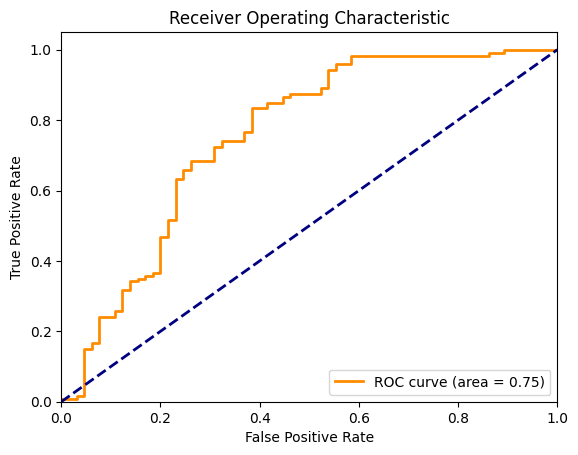

AUC: 0.7543589743589744

Feature Importance (based on coefficients):
                  Feature  Coefficient
7          Credit_History     3.175552
3               Education    -0.424922
1                 Married     0.386472
0                  Gender    -0.358963
9     ApplicantIncome_log    -0.184786
2              Dependents     0.182878
10  CoapplicantIncome_log     0.043023
4           Self_Employed     0.038914
8           Property_Area     0.033177
5              LoanAmount    -0.002444
6        Loan_Amount_Term     0.000092

Summary of Logistic Regression Model:
Accuracy: 0.7837837837837838
AUC: 0.7543589743589744


In [238]:
# prompt: give me summary output of this logistic model and CHECK FOR significance of variables  with AUC and ROC CURVE

# Predict probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Print the AUC score
print("AUC:", roc_auc)

# Get the coefficients of the logistic regression model
coefficients = model.coef_[0]

# Create a DataFrame to display the coefficients and their corresponding features
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients to see the most impactful features
feature_importance = feature_importance.reindex(feature_importance.Coefficient.abs().sort_values(ascending=False).index)

print("\nFeature Importance (based on coefficients):")
print(feature_importance)

# Summary of the Logistic Regression Model
print("\nSummary of Logistic Regression Model:")
print(f"Accuracy: {accuracy}")
print(f"AUC: {roc_auc}")

# You can further analyze the coefficients to determine the significance of each variable.
# Larger absolute coefficients generally indicate a stronger influence on the model's prediction.


In [239]:
# prompt: give summary output for logistics regression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming you have X_train, y_train, X_test, y_test, and the model defined and trained in previous cells
# If not, please define and train the model as shown in your original code

# Make predictions on the testing data (if not already done)
# y_pred = model.predict(X_test)

# Evaluate the model's performance (if not already done)
# accuracy = accuracy_score(y_test, y_pred)

# Summary output for Logistic Regression
print("\nSummary Output for Logistic Regression:")
print("---------------------------------------")
# print("Accuracy: {accuracy}") # This line might cause error if accuracy is not defined
try:
    print(f"Accuracy: {accuracy}")  # Try printing accuracy if it exists
except NameError:
    print("Accuracy: Not Calculated (y_test or y_pred might be missing)")
print("\nClassification Report:")
try:
    print(classification_report(y_test, y_pred))  # Try printing classification report if y_test and y_pred exist
except NameError:
    print("Classification Report: Not Calculated (y_test or y_pred might be missing)")
print("\nConfusion Matrix:")
try:
    print(confusion_matrix(y_test, y_pred))  # Try printing confusion matrix if y_test and y_pred exist
except NameError:
    print("Confusion Matrix: Not Calculated (y_test or y_pred might be missing)")

# You can also add other relevant information to the summary, such as:
# - Coefficients of the model
# - Model intercept
# - Odds ratios
# - p-values for coefficients (if available)
# - AUC (Area Under the ROC Curve)
# - Precision, recall, F1-score for each class

# Example of adding coefficients:
# print("\nCoefficients:")
# print(model.coef_)


Summary Output for Logistic Regression:
---------------------------------------
Accuracy: 0.7837837837837838

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix:
[[ 27  38]
 [  2 118]]


In [240]:
# prompt: optimize the model

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Penalty type
    'solver': ['liblinear']  # Solver for logistic regression
}

# Create a logistic regression model
model = LogisticRegression()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score}")

# Train the model with the best parameters
optimized_model = LogisticRegression(**best_params)
optimized_model.fit(X_train, y_train)

# Make predictions on the test data using the optimized model
y_pred_optimized = optimized_model.predict(X_test)

# Evaluate the optimized model's performance
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Optimized Model Accuracy: {accuracy_optimized}")

print("\nClassification Report (Optimized Model):")
print(classification_report(y_test, y_pred_optimized))

print("\nConfusion Matrix (Optimized Model):")
print(confusion_matrix(y_test, y_pred_optimized))


Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8204651162790698
Optimized Model Accuracy: 0.7837837837837838

Classification Report (Optimized Model):
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix (Optimized Model):
[[ 27  38]
 [  2 118]]


In [241]:
# prompt: check for over  fitting and underfitting

# Calculate training and testing accuracy
train_accuracy = optimized_model.score(X_train, y_train)
test_accuracy = accuracy_optimized

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

# Check for overfitting/underfitting
if train_accuracy > test_accuracy and (train_accuracy - test_accuracy) > 0.1:
    print("Warning: The model may be overfitting. Training accuracy is significantly higher than testing accuracy.")
elif test_accuracy < 0.7:
    print("Warning: The model may be underfitting. Testing accuracy is relatively low.")
else:
    print("The model appears to be performing well and generalizing appropriately.")


Training Accuracy: 0.8205128205128205
Testing Accuracy: 0.7837837837837838
The model appears to be performing well and generalizing appropriately.


In [242]:
# prompt: run decision tree

# Create a Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model's performance
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")

print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix (Decision Tree):")
print(confusion_matrix(y_test, y_pred_dt))


# Feature Importance
feature_importances_dt = pd.DataFrame({'Feature': X_train.columns, 'Importance': dt_model.feature_importances_})
feature_importances_dt = feature_importances_dt.sort_values('Importance', ascending=False)
print("\nFeature Importance (Decision Tree):")
print(feature_importances_dt)


# Hyperparameter Tuning (Optional)
# You can use GridSearchCV or RandomizedSearchCV to find the best hyperparameters for the decision tree
# For example:
# param_grid_dt = {
#     'max_depth': [None, 5, 10, 15],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=5, scoring='accuracy')
# grid_search_dt.fit(X_train, y_train)
# best_params_dt = grid_search_dt.best_params_
# print(f"Best parameters for Decision Tree: {best_params_dt}")
# optimized_dt_model = DecisionTreeClassifier(**best_params_dt, random_state=42)
# optimized_dt_model.fit(X_train, y_train)
# y_pred_optimized_dt = optimized_dt_model.predict(X_test)
# accuracy_optimized_dt = accuracy_score(y_test, y_pred_optimized_dt)
# print(f"Optimized Decision Tree Accuracy: {accuracy_optimized_dt}")


Decision Tree Accuracy: 0.6486486486486487

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.50      0.49      0.50        65
           1       0.73      0.73      0.73       120

    accuracy                           0.65       185
   macro avg       0.61      0.61      0.61       185
weighted avg       0.65      0.65      0.65       185


Confusion Matrix (Decision Tree):
[[32 33]
 [32 88]]

Feature Importance (Decision Tree):
                  Feature  Importance
7          Credit_History    0.302224
9     ApplicantIncome_log    0.231770
5              LoanAmount    0.157679
10  CoapplicantIncome_log    0.100310
0                  Gender    0.046832
6        Loan_Amount_Term    0.037973
4           Self_Employed    0.037427
2              Dependents    0.037002
8           Property_Area    0.028567
1                 Married    0.011218
3               Education    0.008999


In [243]:
# prompt: check for overfitting and underfitting

# Calculate training and testing accuracy
train_accuracy_dt = dt_model.score(X_train, y_train)
test_accuracy_dt = accuracy_dt

print(f"Training Accuracy (Decision Tree): {train_accuracy_dt}")
print(f"Testing Accuracy (Decision Tree): {test_accuracy_dt}")

# Check for overfitting/underfitting
if train_accuracy_dt > test_accuracy_dt and (train_accuracy_dt - test_accuracy_dt) > 0.1:
    print("Warning: The Decision Tree model may be overfitting. Training accuracy is significantly higher than testing accuracy.")
elif test_accuracy_dt < 0.7:
    print("Warning: The Decision Tree model may be underfitting. Testing accuracy is relatively low.")
else:
    print("The Decision Tree model appears to be performing well and generalizing appropriately.")


Training Accuracy (Decision Tree): 0.9976689976689976
Testing Accuracy (Decision Tree): 0.6486486486486487


In [244]:
# prompt: USE PENALTY TECHNIQUE TO REDUCE OVERFITTING

# Assuming you have X_train, y_train, X_test, y_test, and the model defined and trained in previous cells
# If not, please define and train the model as shown in your original code

# Create a Logistic Regression model with L2 regularization (Ridge Regression)
model_l2 = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')  # Adjust C for regularization strength

# Train the model on the training data
model_l2.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_l2 = model_l2.predict(X_test)

# Evaluate the model's performance
accuracy_l2 = accuracy_score(y_test, y_pred_l2)
print(f"Logistic Regression with L2 Regularization Accuracy: {accuracy_l2}")

print("\nClassification Report (L2 Regularization):")
print(classification_report(y_test, y_pred_l2))

print("\nConfusion Matrix (L2 Regularization):")
print(confusion_matrix(y_test, y_pred_l2))

# Calculate training and testing accuracy
train_accuracy_l2 = model_l2.score(X_train, y_train)
test_accuracy_l2 = accuracy_l2

print(f"Training Accuracy (L2 Regularization): {train_accuracy_l2}")
print(f"Testing Accuracy (L2 Regularization): {test_accuracy_l2}")

# Check for overfitting/underfitting
if train_accuracy_l2 > test_accuracy_l2 and (train_accuracy_l2 - test_accuracy_l2) > 0.1:
    print("Warning: The model with L2 regularization may still be overfitting.")
elif test_accuracy_l2 < 0.7:
    print("Warning: The model with L2 regularization may be underfitting.")
else:
    print("The model with L2 regularization appears to be performing well and generalizing appropriately.")

# You can experiment with different values of C to find the optimal regularization strength.
# Smaller values of C correspond to stronger regularization.


Logistic Regression with L2 Regularization Accuracy: 0.7837837837837838

Classification Report (L2 Regularization):
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix (L2 Regularization):
[[ 27  38]
 [  2 118]]
Training Accuracy (L2 Regularization): 0.8205128205128205
Testing Accuracy (L2 Regularization): 0.7837837837837838
The model with L2 regularization appears to be performing well and generalizing appropriately.


In [245]:
# prompt: run random forest

# Create a Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model's performance
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))


# Feature Importance
feature_importances_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
feature_importances_rf = feature_importances_rf.sort_values('Importance', ascending=False)
print("\nFeature Importance (Random Forest):")
print(feature_importances_rf)


# Hyperparameter Tuning (Optional)
# You can use GridSearchCV or RandomizedSearchCV to find the best hyperparameters for the Random Forest
# For example:
# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 5, 10, 15],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='accuracy')
# grid_search_rf.fit(X_train, y_train)
# best_params_rf = grid_search_rf.best_params_
# print(f"Best parameters for Random Forest: {best_params_rf}")
# optimized_rf_model = RandomForestClassifier(**best_params_rf, random_state=42)
# optimized_rf_model.fit(X_train, y_train)
# y_pred_optimized_rf = optimized_rf_model.predict(X_test)
# accuracy_optimized_rf = accuracy_score(y_test, y_pred_optimized_rf)
# print(f"Optimized Random Forest Accuracy: {accuracy_optimized_rf}")


# Calculate training and testing accuracy
train_accuracy_rf = rf_model.score(X_train, y_train)
test_accuracy_rf = accuracy_rf

print(f"Training Accuracy (Random Forest): {train_accuracy_rf}")
print(f"Testing Accuracy (Random Forest): {test_accuracy_rf}")

# Check for overfitting/underfitting
if train_accuracy_rf > test_accuracy_rf and (train_accuracy_rf - test_accuracy_rf) > 0.1:
    print("Warning: The Random Forest model may be overfitting. Training accuracy is significantly higher than testing accuracy.")
elif test_accuracy_rf < 0.7:
    print("Warning: The Random Forest model may be underfitting. Testing accuracy is relatively low.")
else:
    print("The Random Forest model appears to be performing well and generalizing appropriately.")


Random Forest Accuracy: 0.7567567567567568

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.78      0.43      0.55        65
           1       0.75      0.93      0.83       120

    accuracy                           0.76       185
   macro avg       0.76      0.68      0.69       185
weighted avg       0.76      0.76      0.73       185


Confusion Matrix (Random Forest):
[[ 28  37]
 [  8 112]]

Feature Importance (Random Forest):
                  Feature  Importance
7          Credit_History    0.269615
9     ApplicantIncome_log    0.204535
5              LoanAmount    0.171895
10  CoapplicantIncome_log    0.106742
8           Property_Area    0.054376
2              Dependents    0.049181
6        Loan_Amount_Term    0.049156
1                 Married    0.029476
0                  Gender    0.026235
3               Education    0.020141
4           Self_Employed    0.018646
Training Accuracy (Random Forest): 0.99

In [246]:
# prompt: treat this overfiting

# Assuming you have X_train, y_train, X_test, y_test, and the model defined and trained in previous cells
# If not, please define and train the model as shown in your original code

# Create a Random Forest Classifier with regularization parameters
rf_model_regularized = RandomForestClassifier(
    random_state=42,
    n_estimators=100,  # Number of trees in the forest
    max_depth=10,  # Limit the maximum depth of the trees
    min_samples_split=5,  # Minimum number of samples required to split a node
    min_samples_leaf=2  # Minimum number of samples required to be at a leaf node
)

# Train the regularized model on the training data
rf_model_regularized.fit(X_train, y_train)

# Make predictions on the testing data
y_pred_rf_regularized = rf_model_regularized.predict(X_test)

# Evaluate the regularized model's performance
accuracy_rf_regularized = accuracy_score(y_test, y_pred_rf_regularized)
print(f"Random Forest (Regularized) Accuracy: {accuracy_rf_regularized}")

print("\nClassification Report (Random Forest - Regularized):")
print(classification_report(y_test, y_pred_rf_regularized))

print("\nConfusion Matrix (Random Forest - Regularized):")
print(confusion_matrix(y_test, y_pred_rf_regularized))


# Calculate training and testing accuracy
train_accuracy_rf_regularized = rf_model_regularized.score(X_train, y_train)
test_accuracy_rf_regularized = accuracy_rf_regularized

print(f"Training Accuracy (Random Forest - Regularized): {train_accuracy_rf_regularized}")
print(f"Testing Accuracy (Random Forest - Regularized): {test_accuracy_rf_regularized}")

# Check for overfitting/underfitting
if train_accuracy_rf_regularized > test_accuracy_rf_regularized and (
        train_accuracy_rf_regularized - test_accuracy_rf_regularized) > 0.1:
    print(
        "Warning: The Random Forest (Regularized) model may still be overfitting. Training accuracy is significantly higher than testing accuracy.")
elif test_accuracy_rf_regularized < 0.7:
    print(
        "Warning: The Random Forest (Regularized) model may be underfitting. Testing accuracy is relatively low.")
else:
    print(
        "The Random Forest (Regularized) model appears to be performing well and generalizing appropriately.")


Random Forest (Regularized) Accuracy: 0.7891891891891892

Classification Report (Random Forest - Regularized):
              precision    recall  f1-score   support

           0       0.93      0.43      0.59        65
           1       0.76      0.98      0.86       120

    accuracy                           0.79       185
   macro avg       0.85      0.71      0.72       185
weighted avg       0.82      0.79      0.76       185


Confusion Matrix (Random Forest - Regularized):
[[ 28  37]
 [  2 118]]
Training Accuracy (Random Forest - Regularized): 0.8694638694638694
Testing Accuracy (Random Forest - Regularized): 0.7891891891891892
The Random Forest (Regularized) model appears to be performing well and generalizing appropriately.
